In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
# local mods
import geo_utils as geo
import clean_utils as clean
from sklearn.cluster import KMeans

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
import numpy as np
import joblib
from pathlib import Path

In [4]:
import random

In [5]:
# Path to the folder containing spreadsheet files
#path = "spreadsheets/*.csv"
#path = "test1/*.xlsx"
#path = "test3/*.xlsx"
#path = "test5/*.xlsx"
path = "test2026-05-29/*.xlsx"

In [6]:
files = glob.glob(path)

# Load each file into a list of DataFrames
df_list = [pd.read_excel(file) for file in files]

# Combine them into one master DataFrame and drop na
master_df = pd.concat(df_list, ignore_index=True)
master_df = master_df.dropna(subset=["intersection","text_on_sign_exact"])

In [7]:
# clean the strings so they have punctuation removed and such
master_df = clean.clean_string_columns(master_df,columns=["text_on_sign_exact"])

In [8]:
# import additional data
coordinates = pd.read_csv("coordinate_dict2026-05-29.csv")
platte_river_points = pd.read_csv("platte_points.csv")

In [9]:
# drop na and transition latitude and longitude strings
# to a float format
coordinates[["latitude", "longitude"]] = (
    coordinates["cd"]
    .dropna()
    .apply(geo.parse_dms_coordinate)
    .apply(pd.Series)
)

In [10]:
# merge the coordinate sheet with the master sheet
# so the data can be trained
training_data_raw = master_df.merge(
    coordinates[["intersection", "latitude", "longitude", "zip", "city"]],
    on="intersection",
    how="left"
)

In [11]:
training_data_raw

,intersection,text_on_sign_exact,code_type,notes,latitude,longitude,zip,city
0,arapahoe-havana,arapahoe road,NaN,NaN,39.595139,-104.866778,80112.0,centennial
1,arapahoe-havana,arapahoe road,NaN,NaN,39.584194,-104.866861,80112.0,centennial
2,arapahoe-jordan,famous daves,storefront_main,NaN,39.594972,-104.821056,80016.0,centennial
3,arapahoe-peoria,bicycles,storefront_main,NaN,39.595083,-104.848167,80112.0,centennial
4,arapahoe-peoria,dog grooming,storefront_main,NaN,39.595083,-104.848167,80112.0,centennial
...,...,...,...,...,...,...,...,...
3336,13th-havana,starbucks,NaN,NaN,39.736472,-104.865833,NaN,aurora
3337,13th-havana,citibank atm,NaN,NaN,39.736472,-104.865833,NaN,aurora
3338,13th-havana,7eleven,NaN,NaN,39.736472,-104.865833,NaN,aurora
3339,13th-havana,perlmutter christine m,NaN,NaN,39.736472,-104.865833,NaN,aurora


In [12]:
training_data_raw.to_csv('training_data_raw.csv')

In [13]:
# create a dataframe that has one row per instersection with
# all of the text combined for that intersection
intersection_df = (
    training_data_raw
    .groupby("intersection")
    .agg({
        "text_on_sign_exact": " ".join,
        "latitude": "first",
        "longitude": "first",
        "zip": "first",
        "city": "first"
    })
    .reset_index()
    .rename(columns={"text_on_sign_exact": "text_blob"})
)

In [14]:
intersection_df = intersection_df.dropna(subset=["latitude","longitude"])

In [15]:
intersection_df.to_csv("output/cleaned_concatenated.csv")

In [16]:
coords = intersection_df[["latitude", "longitude"]]

kmeans = KMeans(n_clusters=4, random_state=42, n_init="auto")

intersection_df["spatial_cluster"] = kmeans.fit_predict(coords)

/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


In [17]:
intersection_df

,intersection,text_blob,latitude,longitude,zip,city,spatial_cluster
1,11th-santafe,armstrong dance center 711 gas is 329 brick bu...,39.733667,-104.998694,80204.0,denver,2
2,11th-syracuse,11th ave syracuse st no turn on red uhaul syra...,39.732917,-104.898806,80220.0,denver,1
3,11th-yosemite,11th ave yosemite st 7 eleven slurpee taw win ...,39.732861,-104.884750,80010.0,aurora,1
4,13th-havana,fired cannabis dia international market taco b...,39.736472,-104.865833,NaN,aurora,1
5,14th-broadway,only one way open during constrcution library ...,39.738472,-104.987444,80202.0,denver,2
...,...,...,...,...,...,...,...
113,quincy-broadway,dip yamaha home theater parasound open marantz...,39.638583,-104.987806,80113.0,englewood,0
114,tennessee-federal,novacane tony pho miracle touch kim son jewele...,39.698611,-105.025083,NaN,sheridan,2
115,tufts-broadway,lucky u motel 4575 office ace hardware welcome...,39.633139,-104.987861,80113.0,englewood,0
116,victorian-mainstreet,park sixty four no parking any time 2 hour par...,39.518111,-104.759889,80138.0,parker,3


In [18]:
#intersection_df = intersection_df[
#    intersection_df["city"].isin(["denver", "englewood", "cherry creek", "aurora"])
#]

In [19]:
intersection_df

,intersection,text_blob,latitude,longitude,zip,city,spatial_cluster
1,11th-santafe,armstrong dance center 711 gas is 329 brick bu...,39.733667,-104.998694,80204.0,denver,2
2,11th-syracuse,11th ave syracuse st no turn on red uhaul syra...,39.732917,-104.898806,80220.0,denver,1
3,11th-yosemite,11th ave yosemite st 7 eleven slurpee taw win ...,39.732861,-104.884750,80010.0,aurora,1
4,13th-havana,fired cannabis dia international market taco b...,39.736472,-104.865833,NaN,aurora,1
5,14th-broadway,only one way open during constrcution library ...,39.738472,-104.987444,80202.0,denver,2
...,...,...,...,...,...,...,...
113,quincy-broadway,dip yamaha home theater parasound open marantz...,39.638583,-104.987806,80113.0,englewood,0
114,tennessee-federal,novacane tony pho miracle touch kim son jewele...,39.698611,-105.025083,NaN,sheridan,2
115,tufts-broadway,lucky u motel 4575 office ace hardware welcome...,39.633139,-104.987861,80113.0,englewood,0
116,victorian-mainstreet,park sixty four no parking any time 2 hour par...,39.518111,-104.759889,80138.0,parker,3


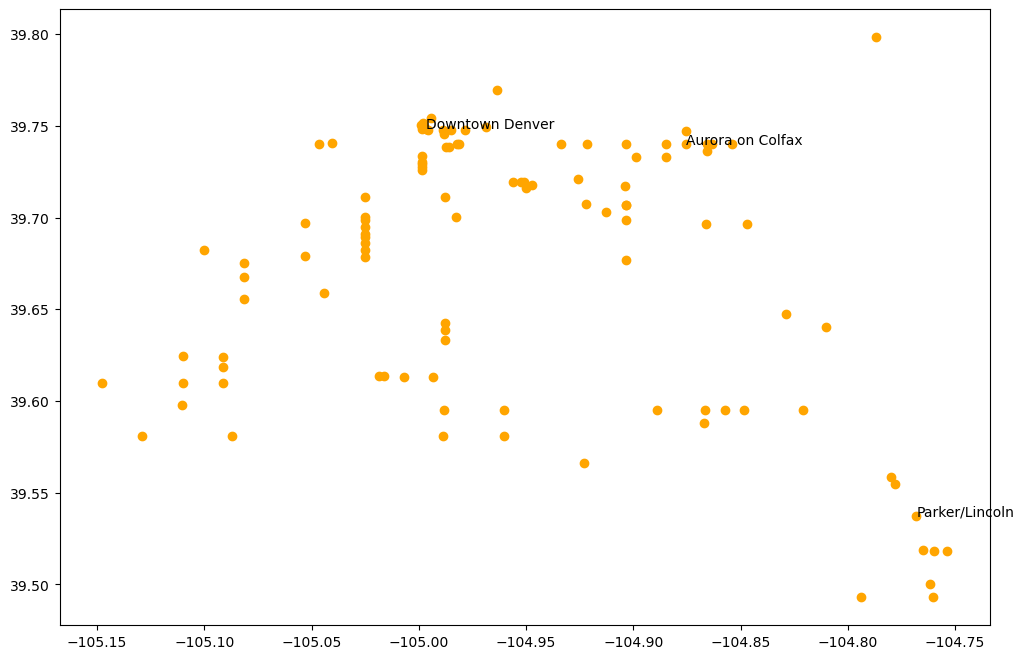

In [20]:
plt.figure(figsize=(12,8))

plt.text(-104.996583333333, 39.74852777777778,"Downtown Denver")
plt.text(-104.875277777777, 39.74022222222222, "Aurora on Colfax")
plt.text(-104.768055555555, 39.53711111111111, "Parker/Lincoln")

plt.scatter(
    intersection_df["longitude"], 
    intersection_df["latitude"], 
    color = "orange", 
    label = "Trained Intersections")
plt.show()

# Predicting a Single Coordinate Based on Language Data from an Intersection
## Distance

In [21]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate great-circle distance between two points on Earth.
    
    Returns distance in kilometers.
    """

    R = 6371  # Earth radius in km

    # convert degrees to radians
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)

    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    # differences
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    # haversine formula
    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

In [25]:
training_data = training_data_raw.dropna(subset=["latitude","longitude"])
training_data.head(3)

,intersection,text_on_sign_exact,code_type,notes,latitude,longitude,zip,city
0,arapahoe-havana,arapahoe road,NaN,NaN,39.595139,-104.866778,80112.0,centennial
1,arapahoe-havana,arapahoe road,NaN,NaN,39.584194,-104.866861,80112.0,centennial
2,arapahoe-jordan,famous daves,storefront_main,NaN,39.594972,-104.821056,80016.0,centennial


In [26]:
# create training data set
def generate_samples(signs, n_samples=50,
                     min_size=3,
                     max_size=7):

    samples = []

    for _ in range(n_samples):

        lower = min(min_size, len(signs))
        upper = min(max_size, len(signs))

        size = random.randint(lower, upper)
        subset = random.sample(signs, size)

        samples.append(" ".join(subset))

    return samples

In [27]:
augmented_rows = []

for intersection, group in training_data.groupby("intersection"):
    
    signs = group["text_on_sign_exact"].dropna().tolist()
    
    lat = group["latitude"].iloc[0]
    lon = group["longitude"].iloc[0]
    
    samples = generate_samples(
        signs,
        n_samples=50,
        min_size=5,
        max_size=10
    )
    
    for sample in samples:
        augmented_rows.append({
            "intersection": intersection,
            "sample_text": sample,
            "lat": lat,
            "lon": lon
        })

In [31]:
test = pd.DataFrame(augmented_rows)
test

,intersection,sample_text,lat,lon
0,11th-santafe,hyder construction tacos selene denver voice 7...,39.733667,-104.998694
1,11th-santafe,aztlan hyder construction quin nicks studio ta...,39.733667,-104.998694
2,11th-santafe,aztlan quin armstrong dance center denver work...,39.733667,-104.998694
3,11th-santafe,hyder construction nicks studio timeos bar tac...,39.733667,-104.998694
4,11th-santafe,sante fe theater nicks studio brick building n...,39.733667,-104.998694
...,...,...,...,...
5395,yale-wadsworth,wild birds unlimited stanley steemer lazboy,39.667778,-105.081472
5396,yale-wadsworth,lazboy stanley steemer wild birds unlimited,39.667778,-105.081472
5397,yale-wadsworth,wild birds unlimited lazboy stanley steemer,39.667778,-105.081472
5398,yale-wadsworth,lazboy stanley steemer wild birds unlimited,39.667778,-105.081472


In [36]:
# assign variables
X = intersection_df["text_blob"]

# for using geographical coordinates
y = intersection_df[["latitude", "longitude"]]

# for using kmean clusters
# y = intersection_df["spatial_cluster"]   # or "city", "region_label", etc.

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state= 348#24#2 # 55 #46 # 42
)

In [38]:
coord_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="char",
        ngram_range=(2, 5),
        lowercase=True,
        min_df=2
    )),
    ("regressor", MultiOutputRegressor(
        Ridge(alpha=0.1)
    ))
])

In [39]:
X_test

74     federal evans burger king tmobile sinclair phi...
61     coffee cocktails cocktails coffee cocktails co...
28     one way toll south e470 do not enter do not en...
19     coors field one way blake st 1500 one way noti...
109    spas fireplaces saunas swim spas awaken chirop...
31     studio strawberry mountain atax sushi rocky my...
30     tribe tattoo denver public library thunderbird...
80     street sweeping p this side 3rd friday april t...
29     the pza pizzeria pizza closed colorado histori...
56     tycoon ramen sushi happy hr menus fork and spo...
21     gamma gallery lemonade house 23 clearance 70 g...
100    good times burgers frozen custard suns out bun...
86     the ride speed limit 40 you just proved these ...
92     pet place vet clinic einstein bros cassa varti...
18     midfirst bank key bank 1st ave cook st olive f...
49     first watch us bank nekter legend teriyaki mad...
48     ace hardware rental paint cindys gifts chiropr...
83     propane fast fill fast p

In [40]:
# fit the model
# model.fit(X_train, y_train)
coord_model.fit(X_train, y_train)

,steps,"[('tfidf', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [41]:
Path("models").mkdir(exist_ok=True)

coord_model.fit(X_train, y_train)

joblib.dump(coord_model, "models/coord_model.joblib")

['models/coord_model.joblib']

In [42]:
# test out the training data
pred_coords = coord_model.predict(X_test)

pred_df = y_test.copy()
pred_df["pred_latitude"] = pred_coords[:, 0]
pred_df["pred_longitude"] = pred_coords[:, 1]

pred_df.head()

,latitude,longitude,pred_latitude,pred_longitude
74,39.678667,-105.025056,39.653782,-104.922328
61,39.740306,-105.046306,39.726884,-105.006779
28,39.798306,-104.786917,39.691150,-104.966258
19,39.754361,-104.994250,39.690353,-104.968644
109,39.500306,-104.761861,39.620399,-104.933740


In [43]:
# assigning mins and maxs to set bounds for random points
lat_min = min(pred_df["latitude"].min(), pred_df["pred_latitude"].min())
lat_max = max(pred_df["latitude"].max(), pred_df["pred_latitude"].min())
long_min = min(pred_df["longitude"].min(),pred_df["pred_longitude"].min())
long_max = max(pred_df["longitude"].max(), pred_df["longitude"].max())

In [44]:
# create random points for latitude and longitude
np.random.seed(28)

pred_df["random_latitude"] = np.random.uniform(
    lat_min,
    lat_max,
    size=len(pred_df)
)

pred_df["random_longitude"] = np.random.uniform(
    long_min,
    long_max,
    size=len(pred_df)
)

In [45]:
# append random error to spreadsheet
pred_df["random_error_km"] = haversine_distance(
    pred_df["latitude"],
    pred_df["longitude"],
    pred_df["random_latitude"],
    pred_df["random_longitude"]
)

In [46]:
mae_lat = mean_absolute_error(y_test["latitude"], pred_df["pred_latitude"])
mae_lng = mean_absolute_error(y_test["longitude"], pred_df["pred_longitude"])

print("Latitude MAE:", mae_lat)
print("Longitude MAE:", mae_lng)

Latitude MAE: 0.04601053515427302
Longitude MAE: 0.09388810368134091


In [47]:
pred_df["error_km"] = haversine_distance(
    pred_df["latitude"],
    pred_df["longitude"],
    pred_df["pred_latitude"],
    pred_df["pred_longitude"]
)

pred_df[[
    "latitude",
    "longitude",
    "pred_latitude",
    "pred_longitude",
    "error_km"
]].head(7)

,latitude,longitude,pred_latitude,pred_longitude,error_km
74,39.678667,-105.025056,39.653782,-104.922328,9.218090
61,39.740306,-105.046306,39.726884,-105.006779,3.694824
28,39.798306,-104.786917,39.691150,-104.966258,19.418545
19,39.754361,-104.994250,39.690353,-104.968644,7.446651
109,39.500306,-104.761861,39.620399,-104.933740,19.885429
31,39.728944,-104.998583,39.668402,-104.958020,7.573906
30,39.727333,-104.998667,39.698113,-104.980818,3.590034


In [48]:
print("Mean error in km:", pred_df["error_km"].mean())
print("Median error in km:", pred_df["error_km"].median())

Mean error in km: 10.358881322054584
Median error in km: 9.8628391880704


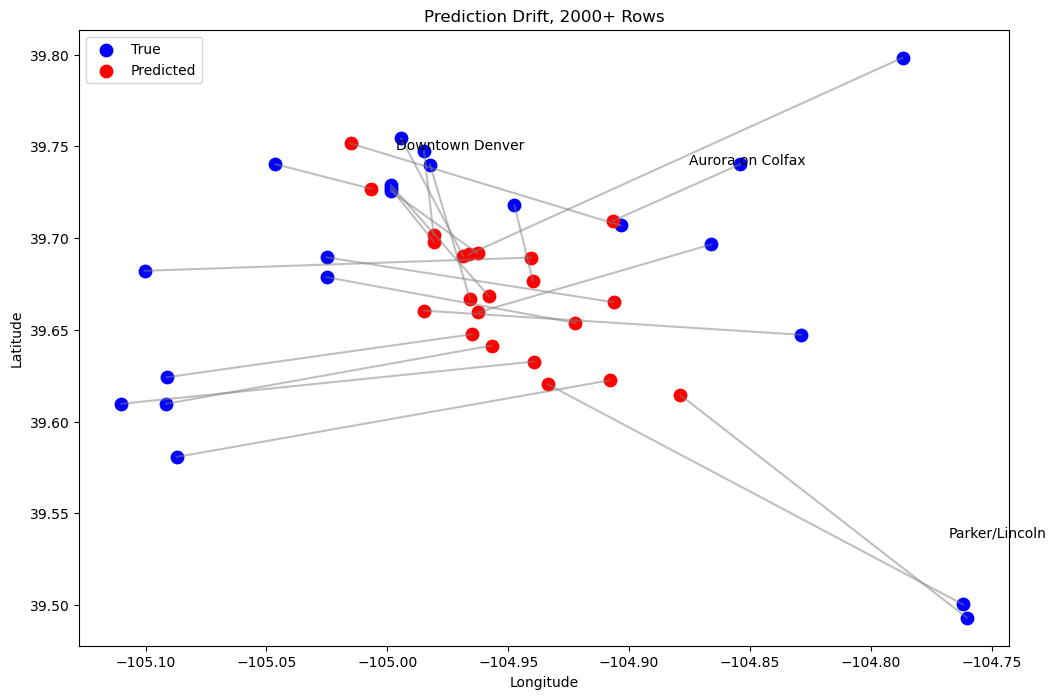

In [49]:
plt.figure(figsize=(12,8))

plt.text(-104.996583333333, 39.74852777777778,"Downtown Denver")
plt.text(-104.875277777777, 39.74022222222222, "Aurora on Colfax")
plt.text(-104.768055555555, 39.53711111111111, "Parker/Lincoln")


# true locations
plt.scatter(
    pred_df["longitude"],
    pred_df["latitude"],
    color="blue",
    label="True",
    s=80
)

# predicted locations
plt.scatter(
    pred_df["pred_longitude"],
    pred_df["pred_latitude"],
    color="red",
    label="Predicted",
    s=80
)

# arrows / lines
for _, row in pred_df.iterrows():

    plt.plot(
        [row["longitude"], row["pred_longitude"]],
        [row["latitude"], row["pred_latitude"]],
        color="gray",
        alpha=0.5
    )



plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title("Prediction Drift, 2000+ Rows")

plt.legend()

plt.savefig("prediction_drift2000_rows.png")

plt.show()

In [ ]:
plt.figure(figsize=(12,8))

plt.text(
    -104.996583333333,
    39.74852777777778,
    "Downtown Denver"
)

plt.text(
    -104.875277777777,
    39.74022222222222,
    "Aurora on Colfax"
)
plt.text(
    -104.768055555555,
    39.53711111111111, 
    "Parker/Lincoln")

# TRUE LOCATIONS
plt.scatter(
    pred_df["longitude"],
    pred_df["latitude"],
    color="blue",
    label="True",
    s=80
)

# MODEL PREDICTIONS
plt.scatter(
    pred_df["pred_longitude"],
    pred_df["pred_latitude"],
    color="red",
    label="Model Prediction",
    s=80
)

# RANDOM PREDICTIONS
plt.scatter(
    pred_df["random_longitude"],
    pred_df["random_latitude"],
    color="green",
    label="Random Prediction",
    s=80,
    alpha=0.7
)

# MODEL LINES + ERROR LABELS
for _, row in pred_df.iterrows():

    # model prediction line
    plt.plot(
        [row["longitude"], row["pred_longitude"]],
        [row["latitude"], row["pred_latitude"]],
        color="gray",
        alpha=0.5
    )

    # midpoint for annotation
    mid_x = (
        row["longitude"] +
        row["pred_longitude"]
    ) / 2

    mid_y = (
        row["latitude"] +
        row["pred_latitude"]
    ) / 2

    # model error label
    plt.text(
        mid_x,
        mid_y,
        f"{row['error_km']:.1f} km",
        fontsize=7,
        alpha=0.7,
        color="black"
    )

# RANDOM LINES
for _, row in pred_df.iterrows():

    plt.plot(
        [row["longitude"], row["random_longitude"]],
        [row["latitude"], row["random_latitude"]],
        color="green",
        alpha=0.25,
        linestyle="dashed"
    )

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title("Model vs Random Geographic Prediction Drift")

plt.legend()

plt.savefig("test_random_vs_model.png", dpi=300)

plt.show()

In [162]:
print("MODEL")
print(pred_df["error_km"].describe())

print("\nRANDOM")
print(pred_df["random_error_km"].describe())

MODEL
count    21.000000
mean     10.048955
std       5.594094
min       0.558346
25%       5.874896
50%       8.257953
75%      14.910182
max      20.988294
Name: error_km, dtype: float64

RANDOM
count    21.000000
mean     20.796615
std       7.515162
min       6.955063
25%      18.320546
50%      21.603133
75%      26.013478
max      32.558594
Name: random_error_km, dtype: float64


In [34]:
query = "taqueria mercado pho celulares"

predicted_coords = coord_model.predict([query])

pred_lat = predicted_coords[0][0]
pred_lon = predicted_coords[0][1]

print(pred_lat, pred_lon)

39.70767322688775 -104.9558366324209


# Predict Possible Areas Based on Intersection Text Data
# using "Neighbors

In [35]:
# grab the vectorizer to visualize
# vectorizer = model.named_steps["tfidf"]
vectorizer = coord_model.named_steps["tfidf"]

X_all_tfidf = vectorizer.transform(intersection_df["text_blob"])

In [36]:
from sklearn.neighbors import NearestNeighbors

nn_model = NearestNeighbors(
    n_neighbors=5,
    metric="cosine"
)

nn_model.fit(X_all_tfidf)

,n_neighbors,5
,radius,1.0
,algorithm,'auto'
,leaf_size,30
,metric,'cosine'
,p,2
,metric_params,None
,n_jobs,None


In [38]:
def find_linguistic_neighbors(text, intersection_df, vectorizer, nn_model, n_neighbors=5):
    text_vec = vectorizer.transform([text])

    distances, indices = nn_model.kneighbors(
        text_vec,
        n_neighbors=n_neighbors
    )

    results = intersection_df.iloc[indices[0]].copy()
    results["cosine_distance"] = distances[0]
    results["similarity"] = 1 - results["cosine_distance"]

    return results[
        [
            "intersection",
            "city",
            "latitude",
            "longitude",
            "similarity",
            "text_blob"
        ]
    ]

In [39]:
def plot_knn_triangulation(knn_df, n, actual:tuple):
    knn_df = knn_df[:n]
    average = triangulate_mean(knn_df, n)
    plt.scatter(knn_df["longitude"], knn_df["latitude"],
           label = f"Top {n} Projected Points")
    plt.scatter(actual[0], actual[1], label = "Actual Intersection")
    plt.scatter(average[0], average[1], label = "Triangulation")
    plt.legend()
    plt.show()

In [40]:
def triangulate_mean(knn_df, n):
    knn_df = knn_df[:n]
    knn_longitude_average = knn_df["longitude"].mean()
    knn_latitude_average = knn_df["latitude"].mean()
    return((knn_longitude_average, knn_latitude_average))

In [41]:
# test a query on Grant
query_text = """
taco river autozone pho vietnamnese restaurant crawfish market pho
"""
query_point = (-105.025207, 39.694929) 

test_knn = find_linguistic_neighbors(
    query_text,
    intersection_df,
    vectorizer,
    nn_model,
    n_neighbors=5
)

In [42]:
test_knn

,intersection,city,latitude,longitude,similarity,text_blob
47,colfax-ivanhoe,denver,39.740139,-104.921694,0.183878,yolo rum you only leave once original myxed up...
50,colfax-pennsylvannia,denver,39.740028,-104.981083,0.177639,time offline bargain house tasty thai theride ...
98,tennessee-federal,sheridan,39.698611,-105.025083,0.173381,novacane tony pho miracle touch kim son jewele...
41,bowles-kipling,littleton,39.609694,-105.109972,0.164321,dairy queen big o tires tacos selene hotpot de...
31,arapahoe-havana,centennial,39.595139,-104.866778,0.164270,arapahoe road arapahoe road top golf top golf ...


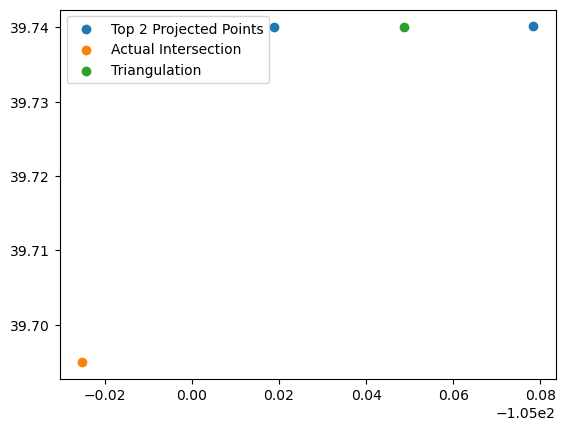

In [43]:
plot_knn_triangulation(test_knn, n= 2, actual = query_point)

In [44]:
# take the top four closest in linguistic space
test_knn = test_knn[:3]

knn_longitude_average = test_knn["longitude"].mean()
knn_latitude_average = test_knn["latitude"].mean()

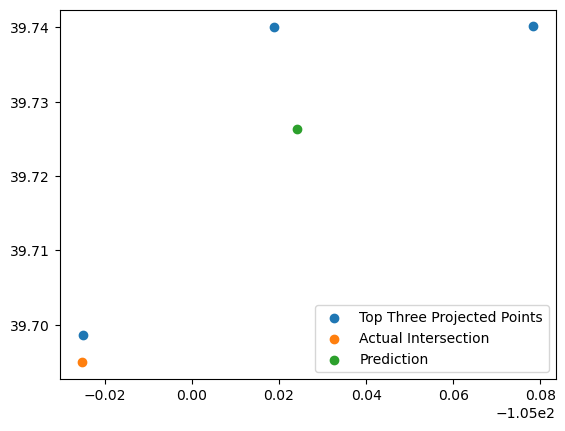

In [45]:
plt.scatter(test_knn["longitude"], test_knn["latitude"],
           label = "Top Three Projected Points")
plt.scatter(query_point[0], query_point[1], label = "Actual Intersection")
plt.scatter(knn_longitude_average, knn_latitude_average, label = "Prediction")
plt.legend()
plt.show()

In [46]:
# visualize the gram weights
X_test_tfidf = vectorizer.transform(X_test)
feature_names = vectorizer.get_feature_names_out()

# model for kmean space
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="char",
        ngram_range=(3, 5),
        lowercase=True,
        min_df=2
    )),
    ("clf", LogisticRegression(
        max_iter=5000
    ))
])

# for kmean clusters
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
feature_names

In [ ]:
# test looking at one row
row = X_test_tfidf[1]
weights = row.toarray()[0]

In [ ]:
tfidf_scores = list(zip(feature_names, weights))

In [ ]:
X_test

In [ ]:
preds = model.predict(X_test)

print(classification_report(y_test, preds))
print(confusion_matrix(y_test, preds))
print(type(preds))

In [ ]:
plt.figure(figsize=(10, 8))

plt.scatter(
    intersection_df["longitude"],   # x-axis
    intersection_df["latitude"],    # y-axis
    c=intersection_df["spatial_cluster"]
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Clusters by Intersection")
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
ax.scatter(coordinates["longitude"], coordinates["latitude"], color="orange")
ax.plot(platte_river_points["platte_long"], platte_river_points["platte_lat"])
ax.set_xlabel("Longitude", weight = "semibold")
ax.set_ylabel("Latitude", weight="semibold")
ax.set_title("Intersections in the Greater Denver Metro Area", weight="bold")
fig.show()